### **Endpoints**

1. **EInfo:** Solo para entender la base pubmed y ver qué campos existen.

2. **ESearch:** Para comprobar que la query devuelve resultados razonables y no miles de artículos irrelevantes.    
Probaremos:     
•	una query más amplia para maximizar recall,  
•	una query equilibrada,  
•	y una query más precisa para reducir ruido.  

3. **ESummary:** Para ver una versión ligera del registro y entender qué campos resultan útiles.

4. **EFetch:** Para inspeccionar un registro más completo y decidir con qué texto vamos a indexar.

5. **ELink:** Para ver si merece la pena usar artículos relacionados como expansión de contexto.

### **Extracción de datos**

**1.	Definición de la query temática, estrategia del corpus**   
Se define una consulta de PubMed alineada con el caso de uso, por ejemplo microbiota intestinal e inflamación sistémica.
  
**2.	Búsqueda de artículos con ESearch**  
Se ejecuta la consulta en db=pubmed para obtener la lista de PMIDs (PubMedIDs) de los artículos que cumplen el criterio. ESearch está precisamente pensado para responder a una búsqueda textual con los identificadores únicos de los registros encontrados.  
  
**3.	Recuperación del contenido con EFetch o ESummary**   
A partir de esos PMIDs, se solicitan los datos de cada artículo. ESummary devuelve un resumen estructurado del registro y EFetch permite recuperar el registro completo en un formato como XML, lo que resulta más útil cuando se quiere trabajar con título, abstract y metadatos con mayor detalle.  
  
**4.	Construcción de la estructura del documento indexable**   
Con la información recuperada se construye el texto que se insertará en la base vectorial, una combinación de título, abstract y metadatos relevantes.


**🔗 API Key**

- Crear cuenta aquí: https://www.ncbi.nlm.nih.gov/account/
  
- Luego:	Settings → API Key

**🔗 PubMed Help**
- https://pubmed.ncbi.nlm.nih.gov/help/ 

In [3]:
import sys
print(sys.executable)


/Users/gloriadelriomarquez/Documents/Career/Master Pontia/10. BD vectoriales/Entrega/project/.venv/bin/python3


In [4]:
# Importamos librerias y cargamos API key
import os
from dotenv import load_dotenv
import requests
from xml.etree import ElementTree as ET

import time
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer, util
from google import genai
from IPython.display import display

/Users/gloriadelriomarquez/Documents/Career/Master Pontia/10. BD vectoriales/Entrega/project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
load_dotenv()
ncbi_api_key = os.getenv('NCBI_API_KEY')
google_api_key = os.getenv('GOOGLE_API_KEY')

print("API Key cargada." if (ncbi_api_key and google_api_key) else "API Key no encontrada")

API Key cargada.


### Einfo

In [8]:
base_url="https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"
info_url = base_url+ "einfo.fcgi"

params_search = {
    "retmode": "json",
    "api_key": ncbi_api_key
}

info_response = requests.get(info_url, params=params_search)
info_data = info_response.json()

print(info_data)

{'header': {'type': 'einfo', 'version': '0.3'}, 'einforesult': {'dblist': ['pubmed', 'protein', 'nuccore', 'ipg', 'nucleotide', 'structure', 'genome', 'annotinfo', 'assembly', 'bioproject', 'biosample', 'blastdbinfo', 'books', 'cdd', 'clinvar', 'gap', 'gapplus', 'grasp', 'dbvar', 'gene', 'gds', 'geoprofiles', 'medgen', 'mesh', 'nlmcatalog', 'omim', 'orgtrack', 'pmc', 'proteinclusters', 'pcassay', 'protfam', 'pccompound', 'pcsubstance', 'seqannot', 'snp', 'sra', 'taxonomy', 'biocollections', 'gtr'], 'dbinfo': []}}


### Esearch

In [ ]:
# BUSCAR ARTÍCULOS (ESearch)
def search_pubmed_ids_trial(terms:str, n:int):
    base_url="https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"
    search_url = base_url+"esearch.fcgi"

    params_search = {
        "db": "pubmed",
        "term": terms ,
        "retmax": n, # Total number of UIDs from the retrieved
        "retmode": "json", # format of the returned output
        "api_key": ncbi_api_key
    }

    response = requests.get(search_url, params=params_search)
    response.raise_for_status()
    data = response.json()

    esearch_result = data.get("esearchresult", {})
    pm_ids = esearch_result.get("idlist", [])
    translationset = esearch_result.get("translationset", [])

    return pm_ids, translationset

In [ ]:
pm_ids, translationset = search_pubmed_ids_trial(terms="gut microbiome inflammation", n=1)  
print("PMIDs encontrados:", pm_ids)

PMIDs encontrados: ['41874246']


In [77]:
# Automatic Term Mapping (ATM)
translationset

[{'from': 'gut microbiome',
  'to': '"gastrointestinal microbiome"[MeSH Terms] OR ("gastrointestinal"[All Fields] AND "microbiome"[All Fields]) OR "gastrointestinal microbiome"[All Fields] OR ("gut"[All Fields] AND "microbiome"[All Fields]) OR "gut microbiome"[All Fields]'},
 {'from': 'inflammation',
  'to': '"inflammation"[MeSH Terms] OR "inflammation"[All Fields] OR "inflammations"[All Fields] OR "inflammation\'s"[All Fields]'}]

#### Filtramos por Status = MEDLINE 

Para garantizar que el corpus esté compuesto únicamente por registros completamente procesados e indexados, la consulta a PubMed mediante `ESearch` se restringe al subconjunto MEDLINE añadiendo `medline[sb]` a la query.

Ejemplo: ```text (query_original) AND medline[sb ```

1. **Calidad de los datos**
   * Tienen metadatos completos.
   * Han pasado procesos de validación.
   * Incluyen información estructurada fiable.

2. **Estabilidad**
   Los estados intermedios pueden cambiar con el tiempo, modificando título o abstract. Esto es crítico en sistemas con **embeddings**:
   * ⚠️ **Cambios en texto** = Embeddings inconsistentes.
   * ⚠️ **Recalculo:** Obliga a procesar el vector de nuevo.

3. **Reducción de ruido**
   * Evita artículos incompletos.
   * Reduce duplicidades potenciales.
   * Mejora la precisión en el *retrieval*.

4. **Coherencia en sistemas RAG**
   En arquitecturas de recuperación semántica, se necesita información consistente y estable. **MEDLINE** garantiza esa base sólida para los modelos.


#### Estrategia  

🔹 Nivel 1 → ESearch (pre-filtrado)   
- solo MEDLINE
- solo con abstract

🔹 Nivel 2 → parsing (validación final)   
- asegurar que abstract existe y no está vacío 


In [ ]:
def search_pubmed_ids(
    terms: str,
    n: int,
    medline_only: bool = True,
    require_abstract: bool = True,
    use_history: bool = False
):
    base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"
    search_url = base_url + "esearch.fcgi"

    filters = []

    if medline_only:
        filters.append("medline[sb]")

    if require_abstract:
        filters.append("hasabstract")

    # Construcción final del término
    if filters:
        final_term = f"({terms}) AND " + " AND ".join(filters)
    else:
        final_term = terms

    params_search = {
        "db": "pubmed",
        "term": final_term,
        "retmax": n,
        "retmode": "json",
        "api_key": ncbi_api_key,
    }

    if use_history:
        params_search["usehistory"] = "y"

    response = requests.get(search_url, params=params_search, timeout=60)
    response.raise_for_status()
    data = response.json()

    esearch_result = data.get("esearchresult", {})

    result = {
        "pm_ids": esearch_result.get("idlist", []),
        "translationset": esearch_result.get("translationset", []),
        "count": esearch_result.get("count"),
        "query_used": final_term  # 👈 MUY útil para debug
    }

    if use_history:
        result["webenv"] = esearch_result.get("webenv")
        result["query_key"] = esearch_result.get("querykey")

    return result

In [ ]:
result = search_pubmed_ids(
    terms="gut microbiota AND inflammation",
    n=1,
    medline_only=True,
    require_abstract=True
)

print(result["query_used"])
print(result["count"])
print(result["pm_ids"][:5])

(gut microbiota AND inflammation) AND medline[sb] AND hasabstract
20526
['41869364']


### Efetch

Para la recuperación de los registros desde PubMed mediante EFetch, se utilizará preferentemente el modo retmode=xml. Aunque formatos como text o html pueden resultar más legibles para inspección manual, el formato XML ofrece una estructura jerárquica explícita que facilita la extracción automática de campos relevantes como PMID, ArticleTitle, AbstractText, journal y fecha de publicación. Por este motivo, XML resulta más adecuado para integrarlo en el pipeline de preprocesado e indexación del sistema RAG.

#### Cómo leer la estructura general

Un PubmedArticle combina dos bloques:  
  
•	**MedlineCitation:** metadatos descriptivos del artículo.  
•	**PubmedData:** metadatos adicionales, sobre todo de historial de publicación, procesamiento e identificadores.  

In [ ]:
# OBTENER DETALLE (EFetch)

def fetch_pubmed_data(ids: list[str]):
    base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"
    fetch_url = base_url + "efetch.fcgi"

    params_fetch = {
        "db": "pubmed",
        "id": ",".join(pm_ids),
        "retmode": "xml", # text, html, xml --> usamos xml por ser un formato más estructurado y consistente para extraer campos 
        "api_key": ncbi_api_key
    }

    response = requests.get(fetch_url, params=params_fetch)
    response.raise_for_status()
    return response

In [ ]:
# Pedimos 1 solo artículo para analizar la salida
result = search_pubmed_ids(terms="gut microbiome inflammation", n=1)   
fetch_response = fetch_pubmed_data(result['pm_ids'])

In [105]:
import xml.dom.minidom

xml_str = fetch_response.text
parsed = xml.dom.minidom.parseString(xml_str)

pretty_xml = parsed.toprettyxml(indent="  ")
print(pretty_xml)

<?xml version="1.0" ?>
<!DOCTYPE PubmedArticleSet
  PUBLIC '-//NLM//DTD PubMedArticle, 1st January 2025//EN'
  'https://dtd.nlm.nih.gov/ncbi/pubmed/out/pubmed_250101.dtd'>
<PubmedArticleSet>
  

  <PubmedArticle>
    <MedlineCitation Status="Publisher" Owner="NLM">
      <PMID Version="1">41871943</PMID>
      <DateRevised>
        <Year>2026</Year>
        <Month>03</Month>
        <Day>23</Day>
      </DateRevised>
      <Article PubModel="Print-Electronic">
        <Journal>
          <ISSN IssnType="Electronic">1468-3288</ISSN>
          <JournalIssue CitedMedium="Internet">
            <PubDate>
              <Year>2026</Year>
              <Month>Mar</Month>
              <Day>23</Day>
            </PubDate>
          </JournalIssue>
          <Title>Gut</Title>
          <ISOAbbreviation>Gut</ISOAbbreviation>
        </Journal>
        <ArticleTitle>Dysbiotic microbiota trigger colitis-associated colorectal cancer and imprint a distinctive bile acid profile in a PSC-IBD model.</

Estructura de la salida: 

In [106]:
# Ecploramos la estrucura en arbol del xml 
def explore_xml(element, level=0):
    print("  " * level + element.tag)
    for child in element:
        explore_xml(child, level + 1)

root = ET.fromstring(fetch_response.content)
explore_xml(root)

PubmedArticleSet
  PubmedArticle
    MedlineCitation
      PMID
      DateRevised
        Year
        Month
        Day
      Article
        Journal
          ISSN
          JournalIssue
            PubDate
              Year
              Month
              Day
          Title
          ISOAbbreviation
        ArticleTitle
        ELocationID
        ELocationID
        Abstract
          AbstractText
          AbstractText
          AbstractText
            sup
            sup
          AbstractText
            sup
            sup
          AbstractText
          CopyrightInformation
        AuthorList
          Author
            LastName
            ForeName
            Initials
            Identifier
            AffiliationInfo
              Affiliation
            AffiliationInfo
              Affiliation
            AffiliationInfo
              Affiliation
            AffiliationInfo
              Affiliation
          Author
            LastName
            ForeName
       

In [ ]:
# Pedimos varios artículos para analizar la salida
result= search_pubmed_ids(terms="gut microbiome inflammation", n=10)  
fetch_response = fetch_pubmed_data(result['pm_ids'])

In [108]:
root = ET.fromstring(fetch_response.content)

for i, article in enumerate(root.findall(".//PubmedArticle")):
    
    pmid = article.findtext(".//PMID")
    title = article.findtext(".//ArticleTitle")
    
    # Algunos abstracts tienen múltiples partes
    abstract_parts = article.findall(".//AbstractText")
    abstract = " ".join([part.text for part in abstract_parts if part.text])
    
    journal = article.findtext(".//Title")
    year = article.findtext(".//PubDate/Year")
    
    print(f"\n--- ARTÍCULO {i+1} ---")
    print(f"PMID: {pmid}")
    print(f"Título: {title}")
    print(f"Journal: {journal}")
    print(f"Año: {year}")
    print(f"Abstract: {abstract[:500]}...")


--- ARTÍCULO 1 ---
PMID: 41871943
Título: Dysbiotic microbiota trigger colitis-associated colorectal cancer and imprint a distinctive bile acid profile in a PSC-IBD model.
Journal: Gut
Año: 2026
Abstract: Primary sclerosing cholangitis-associated UC (PSC-UC) carries excess colorectal neoplasia despite often mild-appearing endoscopy, implicating persistent microscopic inflammation and microbiota-bile acid (BA) dysfunction. To test whether PSC-UC neoplasia is driven by transferable microbiota-mediated inflammation linked to secondary BA loss. Surveillance colonoscopies (2012-2022) from PSC-UC (n=251) and UC-only (n=8839) were compared for segmental endoscopic/histological activity and dysplasia. We...


Analizamos con más ejemplos History y PublicationStatus para determinar si pueden aportar información de cara a posibles actualizaciones de los documetos, pero no llegamos a ver un aporte de valor claro como para incuirlos. 
- **History**: Recoge varias fechas del ciclo de vida editorial y del procesamiento en PubMed, como received, revised, accepted, entrez, pubmed y medline
- **PublicationStatus**  

In [109]:
root = ET.fromstring(fetch_response.content)

for i, article in enumerate(root.findall(".//PubmedArticle")):
    pmid = article.findtext(".//PMID", default="")

    pubmed_data = article.find(".//PubmedData")
    publication_status = pubmed_data.findtext("PublicationStatus", default="") if pubmed_data is not None else ""

    print(f"\n--- ARTÍCULO {i+1} ---")
    print(f"PMID: {pmid}")
    print(f"PublicationStatus: {publication_status}")

    history = pubmed_data.find("History") if pubmed_data is not None else None

    if history is None:
        print("Sin historial")
        continue

    for pub_date in history.findall("PubMedPubDate"):
        status = pub_date.attrib.get("PubStatus", "unknown")
        year = pub_date.findtext("Year", default="")
        month = pub_date.findtext("Month", default="")
        day = pub_date.findtext("Day", default="")
        hour = pub_date.findtext("Hour", default="")
        minute = pub_date.findtext("Minute", default="")

        fecha = f"{year}-{month}-{day}".strip("-")
        hora = f"{hour}:{minute}" if hour or minute else ""

        print(f"  - {status}: {fecha} {hora}".strip())


--- ARTÍCULO 1 ---
PMID: 41871943
PublicationStatus: aheadofprint
- received: 2025-8-13
- accepted: 2026-2-26
- medline: 2026-3-24 0:30
- pubmed: 2026-3-24 0:30
- entrez: 2026-3-23 21:23


## Modelado de datos  

### Texto principal para embeddings
- **ArticleTitle**: Título del artículo
- **AbstractText**: Es el abstract del paper. PubMed aclara además que los abstracts en inglés se toman directamente del artículo publicado y que, si un artículo no tiene abstract publicado, NLM no crea uno. 

### Metadata
- **Journal/Title**: Nombre de la revista que lo publica
- **DateRevised**: Es la fecha en la que el registro de PubMed fue revisado o actualizado en la base de datos. 
- **PubDate:** Es la fecha de publicación. A veces viene completa y a veces solo con el año; PubMed indica que las fechas de publicación pueden ser incompletas y que, para ordenar, cuando faltan mes o día se imputan valores por defecto.  
- **ArticleDate**: fecha completa del artículo. Si está disponible, puede ser mejor candidato que un PubDate incompleto.
- **KeywordList**: Son keywords asociadas al artículo. En la ayuda de PubMed se relaciona con Other Term [ot], es decir, términos no MeSH, a menudo keywords de autor o asignadas por otras organizaciones. 
- **AuthorList** (lista con N posibles autores): Lista de autores.￼
- **Language**: Idioma del artículo
- **ArticleIdList**: Son identificadores únicos del artículo. Entre los disponibles nosotros vamos a almacenar
	- **PMID** = identificador del artículo dentro de PubMed. Ej.: 41869364   
	El PMID sirve muy bien como document_id para nuestro proyecto tu sistema porque viene de PubMed.
	- **DOI** = identificador “global” del artículo en el ecosistema editorial científico. Ej.: 10.3389/fimmu.2026.1714515        
	El DOI también conviene guardarlo porque identifica el paper fuera de PubMed y ayudaría a enlazarlo o deduplicarlo con otras fuentes.

### Estructura del diccionario de salida 
```python
article_dict = {
    "document_id": "pubmed_41869364",
    "source": "pubmed"
    "source_id": "41869364",
    "doi": doi,
    "title": article_title,
    "abstract": abstract_text,
    "embedding_text": f"{article_title}. {abstract_text}".strip(),
    "metadata": {
        "journal": journal_title,
        "language": language,
        "keywords": keyword_list,
        "authors": author_list,
        "pub_date_raw": pub_date_raw,
        "pub_date_normalized": pub_date_normalized,
        "article_date": article_date,
        "date_revised": date_revised,
        "best_date": best_date
    }
}
```

In [110]:
# FETCH: descargar XML
def fetch_pubmed_data(ids: list[str]):
    base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"
    fetch_url = base_url + "efetch.fcgi"

    params_fetch = {
        "db": "pubmed",
        "id": ",".join(ids),  
        "retmode": "xml",
        "api_key": ncbi_api_key
    }

    response = requests.get(fetch_url, params=params_fetch)
    response.raise_for_status()
    return response.text

# Helpers de parsing

def get_text(elem, path, default=None):
    node = elem.find(path)
    if node is not None and node.text:
        return node.text.strip()
    return default


def get_all_texts(elem, path):
    nodes = elem.findall(path)
    values = []
    for node in nodes:
        if node.text and node.text.strip():
            values.append(node.text.strip())
    return values


def parse_author_list(article_elem):
    authors = []
    author_nodes = article_elem.findall(".//AuthorList/Author")

    for author in author_nodes:
        last_name = get_text(author, "LastName")
        fore_name = get_text(author, "ForeName")
        initials = get_text(author, "Initials")

        collective_name = get_text(author, "CollectiveName")

        if collective_name:
            authors.append({
                "collective_name": collective_name
            })
        else:
            authors.append({
                "last_name": last_name,
                "fore_name": fore_name,
                "initials": initials
            })

    return authors


def parse_keyword_list(article_elem):
    keywords = []
    keyword_nodes = article_elem.findall(".//KeywordList/Keyword")

    for kw in keyword_nodes:
        if kw.text and kw.text.strip():
            keywords.append(kw.text.strip())

    return keywords


def parse_article_ids(article_elem):
    article_ids = {
        "pmid": None,
        "doi": None
    }

    # PMID principal
    pmid = get_text(article_elem, ".//MedlineCitation/PMID")
    article_ids["pmid"] = pmid

    # DOI dentro de ArticleIdList
    for article_id in article_elem.findall(".//PubmedData/ArticleIdList/ArticleId"):
        id_type = article_id.attrib.get("IdType")
        if id_type == "doi" and article_id.text:
            article_ids["doi"] = article_id.text.strip()

    return article_ids


def parse_pub_date(article_elem):
    """
    Devuelve:
    - pub_date_raw: representación simple de PubDate
    - article_date: fecha completa si existe
    """
    pub_date_node = article_elem.find(".//Article/Journal/JournalIssue/PubDate")

    year = month = day = None
    medline_date = None

    if pub_date_node is not None:
        year = get_text(pub_date_node, "Year")
        month = get_text(pub_date_node, "Month")
        day = get_text(pub_date_node, "Day")
        medline_date = get_text(pub_date_node, "MedlineDate")

    if year:
        pub_date_raw = "-".join([x for x in [year, month, day] if x])
    else:
        pub_date_raw = medline_date

    article_date = None
    article_date_node = article_elem.find(".//Article/ArticleDate")
    if article_date_node is not None:
        a_year = get_text(article_date_node, "Year")
        a_month = get_text(article_date_node, "Month")
        a_day = get_text(article_date_node, "Day")

        if a_year and a_month and a_day:
            article_date = f"{a_year}-{a_month.zfill(2)}-{a_day.zfill(2)}"

    return pub_date_raw, article_date


def parse_date_revised(article_elem):
    date_node = article_elem.find(".//DateRevised")
    if date_node is None:
        return None

    year = get_text(date_node, "Year")
    month = get_text(date_node, "Month")
    day = get_text(date_node, "Day")

    if year and month and day:
        return f"{year}-{month.zfill(2)}-{day.zfill(2)}"
    return None


def parse_abstract(article_elem):
    abstract_nodes = article_elem.findall(".//Article/Abstract/AbstractText")

    parts = []
    for node in abstract_nodes:
        label = node.attrib.get("Label")
        text = "".join(node.itertext()).strip()

        if text:
            if label:
                parts.append(f"{label}: {text}")
            else:
                parts.append(text)

    return " ".join(parts) if parts else None


def choose_best_date(pub_date_raw, article_date):
    return article_date if article_date else pub_date_raw



# PARSE: XML -> lista de dicts

def parse_pubmed_xml_to_dicts(xml_text: str):
    root = ET.fromstring(xml_text)
    articles = []

    for article_elem in root.findall(".//PubmedArticle"):
        article_ids = parse_article_ids(article_elem)

        pmid = article_ids["pmid"]
        doi = article_ids["doi"]

        title = get_text(article_elem, ".//Article/ArticleTitle")
        abstract = parse_abstract(article_elem)
        journal = get_text(article_elem, ".//Article/Journal/Title")
        language_list = get_all_texts(article_elem, ".//Article/Language")
        language = language_list[0] if language_list else None

        keywords = parse_keyword_list(article_elem)
        authors = parse_author_list(article_elem)

        pub_date_raw, article_date = parse_pub_date(article_elem)
        date_revised = parse_date_revised(article_elem)
        best_date = choose_best_date(pub_date_raw, article_date)

        embedding_text = " ".join(
            part for part in [title, abstract] if part
        ).strip()

        article_dict = {
            "document_id": f"pubmed_{pmid}",
            "source": "pubmed",

            "pmid": pmid,
            "doi": doi,

            "title": title,
            "abstract": abstract,
            "embedding_text": embedding_text,

            "metadata": {
                "journal": journal,
                "language": language,
                "keywords": keywords,
                "authors": authors,
                "pub_date_raw": pub_date_raw,
                "article_date": article_date,
                "date_revised": date_revised,
                "best_date": best_date
            }
        }

        articles.append(article_dict)

    return articles

In [ ]:
# PIPELINE 

def build_pubmed_article_dicts(query: str, n: int, medline_only: bool = True):
    results = search_pubmed_ids(query, n, medline_only=medline_only)

    pm_ids = results["pm_ids"]
    translationset = results["translationset"]

    if not pm_ids:
        return {
            "query": query,
            "translationset": translationset,
            "pm_ids": [],
            "articles": []
        }

    xml_text = fetch_pubmed_data(pm_ids)
    articles = parse_pubmed_xml_to_dicts(xml_text)

    return {
        "query": query,
        "translationset": translationset,
        "pm_ids": pm_ids,
        "articles": articles
    }


In [ ]:
from pprint import pprint

result = build_pubmed_article_dicts(query="hashimoto thyroiditis microbiota",n= 3)


print(result["query"],"\n")
print(result["translationset"],"\n")
print(result["pm_ids"],"\n")
pprint(result["articles"][0],sort_dicts=False)

hashimoto thyroiditis microbiota 

[{'from': 'hashimoto thyroiditis', 'to': '"hashimoto disease"[MeSH Terms] OR ("hashimoto"[All Fields] AND "disease"[All Fields]) OR "hashimoto disease"[All Fields] OR ("hashimoto"[All Fields] AND "thyroiditis"[All Fields]) OR "hashimoto thyroiditis"[All Fields]'}, {'from': 'microbiota', 'to': '"microbiota"[MeSH Terms] OR "microbiota"[All Fields] OR "microbiotas"[All Fields] OR "microbiota\'s"[All Fields] OR "microbiotae"[All Fields]'}, {'from': 'medline[sb]', 'to': '"medlinestatus_medline"[all]'}] 

['41798186', '41698880', '41437012'] 

{'document_id': 'pubmed_41798186',
 'source': 'pubmed',
 'pmid': '41798186',
 'doi': '10.3389/fendo.2026.1785878',
 'title': 'The role of gut microbiota in autoimmune thyroid diseases: '
          'nutritional determinants and diet-based modulation.',
 'abstract': "Autoimmune thyroid diseases (AITD), primarily Hashimoto's "
             "thyroiditis and Graves' disease, represent the most common "
             'organ-

 ## Conteo de artículos por query

In [113]:
def count_pubmed_results(query: str):
    base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"

    params = {
        "db": "pubmed",
        "term": query,
        "retmode": "json",
        "retmax": 0  # no queremos IDs, solo conteo
    }

    response = requests.get(base_url, params=params)
    data = response.json()

    return int(data["esearchresult"]["count"])

In [114]:
queries = [
    "gut microbiota AND inflammation",
    "gut microbiota AND systemic inflammation",
    "microbiota[MeSH Terms] AND inflammation[MeSH Terms]"
]

for q in queries:
    print(q, "->", count_pubmed_results(q))

gut microbiota AND inflammation -> 26355
gut microbiota AND systemic inflammation -> 4523
microbiota[MeSH Terms] AND inflammation[MeSH Terms] -> 6597


free text (microbiota) → más amplio (ruido incluido)
añadir “systemic” → reducimos mucho (más específico)
MeSH → más controlado pero diferente cobertura

In [139]:
class GeminiEmbeddingWrapper:
    def __init__(self, model_name="gemini-embedding-2-preview"):
        self.model_name = model_name

    def encode(self, texts, convert_to_tensor=False, show_progress_bar=False, task_type="retrieval_document"):
        import torch, time
        if isinstance(texts, str):
            texts = [texts]
        embeddings = []
        for text in texts:
            result = client.models.embed_content(
                model=self.model_name,
                contents=text,
                config={"task_type": task_type}
            )
            embeddings.append(result.embeddings[0].values)
            time.sleep(0.05)
        tensor = torch.tensor(embeddings)
        return tensor

In [143]:
# PREPARAR CORPUS Y QUERIES

def fetch_pubmed_data(ids: list[str]):
    base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"
    fetch_url = base_url + "efetch.fcgi"

    params_fetch = {
        "db": "pubmed",
        "id": ",".join(ids),
        "retmode": "xml",
        "api_key": ncbi_api_key
    }

    response = requests.get(fetch_url, params=params_fetch, timeout=60)
    response.raise_for_status()
    return response.text

def build_corpus_from_articles(articles):
    """
    Extrae el texto a embeber y conserva referencia al artículo original.
    """
    corpus_texts = []
    corpus_meta = []

    for art in articles:
        corpus_texts.append(art["embedding_text"])
        corpus_meta.append({
            "document_id": art["document_id"],
            "pmid": art["pmid"],
            "title": art["title"],
            "journal": art["metadata"].get("journal"),
            "best_date": art["metadata"].get("best_date")
        })

    return corpus_texts, corpus_meta


# Consultas de prueba para vuestro caso de uso
queries = [
    "gut microbiota and systemic inflammation",
    "intestinal permeability and low-grade inflammation",
    "dietary modulation of gut microbiota",
    "microbiota in autoimmune thyroid disease",
    "probiotics and inflammatory response"
]


# MODELOS A COMPARAR
# - uno generalista
# - uno biomédico de embeddings
# - uno sentence-transformer biomédico

MODELS = {
    "bge-m3": "BAAI/bge-m3",
    "pubmedbert-embeddings": "NeuML/pubmedbert-base-embeddings",
    "s-pubmedbert-medquad": "TimKond/S-PubMedBert-MedQuAD", 
    "gemini-embedding-2-preview": "gemini-embedding-2-preview" 
}

# Metadatos para la tabla comparativa final.
MODEL_INFO = {
    "bge-m3": {
        "type": "generalist",
        "approx_params_millions": 568,
        "notes": "open-source general-purpose embedding model"
    },
    "pubmedbert-embeddings": {
        "type": "biomedical",
        "approx_params_millions": 110,
        "notes": "PubMedBERT adapted for embeddings"
    },
    "s-pubmedbert-medquad": {
        "type": "biomedical-sentence-similarity",
        "approx_params_millions": 110,
        "notes": "PubMedBERT adapted for sentence similarity / retrieval"
    }, 
    "gemini-embedding-2-preview": {
        "type": "API-based",
        "approx_params_millions": None,
        "notes": "Google gemini-embedding-2-preview via Gemini API"
    }

}

# HELPERS

def format_queries_for_model(model_name, queries):
    """
    Algunos modelos, como e5, requieren prefijos tipo 'query:'.
    """
    if "e5" in model_name.lower():
        return [f"query: {q}" for q in queries]
    return queries


def format_corpus_for_model(model_name, corpus):
    """
    Algunos modelos, como e5, requieren prefijos tipo 'passage:'.
    """
    if "e5" in model_name.lower():
        return [f"passage: {doc}" for doc in corpus]
    return corpus


def load_models(model_dict, device):
    """
    Carga los modelos compatibles con sentence-transformers.
    Si alguno falla, se omite para no romper toda la comparativa.
    """
    loaded_models = {}
    failed_models = {}

    for alias, official_name in model_dict.items():

        print(f"Cargando modelo: {alias} -> {official_name}")
        if alias.startswith("gemini"):
            loaded_models[alias] = GeminiEmbeddingWrapper(model_name=official_name)
            continue
        try:
            loaded_models[alias] = SentenceTransformer(
                official_name,
                device=device,
                trust_remote_code=True
            )
        except Exception as exc:
            failed_models[alias] = str(exc)
            print(f"No se pudo cargar {alias}: {exc}")
            print("Se omite este modelo y la comparacion continua con los demas.")

    if not loaded_models:
        raise ValueError("No se pudo cargar ningun modelo compatible.")

    if failed_models:
        print("\nModelos omitidos:")
        for alias, error in failed_models.items():
            print(f"- {alias}: {error}")

    return loaded_models


def encode_corpus_and_queries(models, corpus_texts, queries):
    """
    Genera embeddings para corpus y queries con cada modelo y mide tiempos.
    """
    embeddings = {}

    for model_alias, model in models.items():
        print(f"\nGenerando embeddings con: {model_alias}")


        corpus_input = format_corpus_for_model(model_alias, corpus_texts)
        query_input = format_queries_for_model(model_alias, queries)


        with torch.no_grad():
            start_encoding_corpus = time.time()
            corpus_encode_kwargs = {
                "convert_to_tensor": True,
                "show_progress_bar": False
            }
            query_encode_kwargs = {
                "convert_to_tensor": True,
                "show_progress_bar": False
            }

            if model_alias.startswith("gemini"):
                corpus_encode_kwargs["task_type"] = "retrieval_document"
                query_encode_kwargs["task_type"] = "retrieval_query"

            corpus_emb = model.encode(corpus_input, **corpus_encode_kwargs)
            end_encoding_corpus = time.time()

            start_encoding_queries = time.time()
            query_emb = model.encode(query_input, **query_encode_kwargs)
            end_encoding_queries = time.time()

        corpus_time = end_encoding_corpus - start_encoding_corpus
        query_time = end_encoding_queries - start_encoding_queries

        embeddings[model_alias] = {
            "corpus_embeddings": corpus_emb,
            "query_embeddings": query_emb,
            "dimension": corpus_emb.shape[1],
            "corpus_encoding_time_sec": corpus_time,
            "query_encoding_time_sec": query_time,
            "avg_doc_encoding_time_sec": corpus_time / len(corpus_texts) if corpus_texts else None,
            "avg_query_encoding_time_sec": query_time / len(queries) if queries else None
        }

        print(f"Dimensión embeddings ({model_alias}): {corpus_emb.shape[1]}")
        print(f"Tiempo corpus ({model_alias}): {corpus_time:.4f} s")
        print(f"Tiempo queries ({model_alias}): {query_time:.4f} s")

    return embeddings

def semantic_search_one_query(query_embedding, corpus_embeddings, corpus_meta, top_k=3):
    """
    Realiza búsqueda semántica para una única query.
    """
    hits = util.semantic_search(query_embedding, corpus_embeddings, top_k=top_k)[0]

    results = []
    for rank, hit in enumerate(hits, start=1):
        doc_idx = hit["corpus_id"]
        score = float(hit["score"])

        results.append({
            "rank": rank,
            "score": score,
            "document_id": corpus_meta[doc_idx]["document_id"],
            "pmid": corpus_meta[doc_idx]["pmid"],
            "title": corpus_meta[doc_idx]["title"],
            "journal": corpus_meta[doc_idx]["journal"],
            "best_date": corpus_meta[doc_idx]["best_date"]
        })

    return results


def compare_models_for_queries(models, embeddings, queries, corpus_meta, top_k=3):
    """
    Ejecuta búsqueda semántica para cada query y cada modelo.
    También mide tiempo de búsqueda por query y por modelo.
    """
    detailed_results = []
    summary_results = []

    for q_idx, query_text in enumerate(queries):
        print("\n" + "=" * 100)
        print(f"QUERY: {query_text}")
        print("=" * 100)

        for model_alias in embeddings.keys():
            query_embedding = embeddings[model_alias]["query_embeddings"][q_idx]
            corpus_embeddings = embeddings[model_alias]["corpus_embeddings"]

            search_start = time.time()
            top_hits = semantic_search_one_query(
                query_embedding=query_embedding,
                corpus_embeddings=corpus_embeddings,
                corpus_meta=corpus_meta,
                top_k=top_k
            )
            search_end = time.time()

            search_time = search_end - search_start

            print(f"\n--- Modelo: {model_alias} ---")
            for hit in top_hits:
                print(f"[{hit['rank']}] score={hit['score']:.4f} | PMID={hit['pmid']} | {hit['title']}")

                detailed_results.append({
                    "query": query_text,
                    "model": model_alias,
                    "rank": hit["rank"],
                    "score": hit["score"],
                    "document_id": hit["document_id"],
                    "pmid": hit["pmid"],
                    "title": hit["title"],
                    "journal": hit["journal"],
                    "best_date": hit["best_date"],
                    "search_time_sec": search_time
                })

            summary_results.append({
                "query": query_text,
                "model": model_alias,
                "top_1_score": top_hits[0]["score"],
                "top_1_pmid": top_hits[0]["pmid"],
                "top_1_title": top_hits[0]["title"],
                "search_time_sec": search_time
            })

    df_detailed = pd.DataFrame(detailed_results)
    df_summary = pd.DataFrame(summary_results)

    return df_detailed, df_summary

In [144]:
# TABLAS, GRÁFICOS Y COMPARACIONES 

def build_model_comparison_table(embeddings, df_summary, model_info):
    """
    Construye tabla comparativa final:
    - tipo
    - nº de parámetros aproximado
    - dimensión embedding
    - tiempos
    - score medio top-1
    """
    rows = []

    grouped_scores = (
        df_summary.groupby("model", as_index=False)
        .agg(
            avg_top1_score=("top_1_score", "mean"),
            min_top1_score=("top_1_score", "min"),
            max_top1_score=("top_1_score", "max"),
            avg_search_time_sec=("search_time_sec", "mean")
        )
    )

    score_lookup = grouped_scores.set_index("model").to_dict(orient="index")

    for model_alias, emb_data in embeddings.items():
        info = model_info.get(model_alias, {})

        rows.append({
            "model": model_alias,
            "type": info.get("type"),
            "approx_params_millions": info.get("approx_params_millions"),
            "embedding_dimension": emb_data["dimension"],
            "corpus_encoding_time_sec": round(emb_data["corpus_encoding_time_sec"], 4),
            "query_encoding_time_sec": round(emb_data["query_encoding_time_sec"], 4),
            "avg_doc_encoding_time_sec": round(emb_data["avg_doc_encoding_time_sec"], 6),
            "avg_query_encoding_time_sec": round(emb_data["avg_query_encoding_time_sec"], 6),
            "avg_search_time_sec": round(score_lookup.get(model_alias, {}).get("avg_search_time_sec", float("nan")), 6),
            "avg_top1_score": round(score_lookup.get(model_alias, {}).get("avg_top1_score", float("nan")), 4),
            "min_top1_score": round(score_lookup.get(model_alias, {}).get("min_top1_score", float("nan")), 4),
            "max_top1_score": round(score_lookup.get(model_alias, {}).get("max_top1_score", float("nan")), 4),
            "notes": info.get("notes")
        })

    df_models = pd.DataFrame(rows)
    df_models = df_models.sort_values(by="avg_top1_score", ascending=False).reset_index(drop=True)

    return df_models


def plot_top1_scores(df_summary):
    """
    Gráfico simple con matplotlib: score del primer resultado por query y modelo.
    """
    pivot_df = df_summary.pivot(index="query", columns="model", values="top_1_score")

    ax = pivot_df.plot(kind="bar", figsize=(14, 7))
    ax.set_title("Comparación del score del primer resultado por modelo")
    ax.set_xlabel("Query")
    ax.set_ylabel("Top-1 cosine similarity")
    plt.xticks(rotation=20, ha="right")
    plt.legend(title="Modelo")
    plt.tight_layout()
    plt.show()


def plot_encoding_times(df_models):
    import matplotlib.pyplot as plt
    import numpy as np

    models = df_models["model"]
    corpus_times = df_models["corpus_encoding_time_sec"]
    query_times = df_models["query_encoding_time_sec"]

    x = np.arange(len(models))
    width = 0.4

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Colores
    color_corpus = "tab:blue"
    color_query = "tab:orange"

    # Eje izquierdo → corpus
    bars1 = ax1.bar(x - width/2, corpus_times, width, color=color_corpus, label="Corpus time")
    ax1.set_ylabel("Tiempo corpus (segundos)", color=color_corpus)
    ax1.tick_params(axis='y', labelcolor=color_corpus)

    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=20)

    # Eje derecho → queries
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, query_times, width, color=color_query, label="Query time")
    ax2.set_ylabel("Tiempo queries (segundos)", color=color_query)
    ax2.tick_params(axis='y', labelcolor=color_query)

    # Título
    plt.title("Comparación de tiempos de generación de embeddings")

    # Leyenda combinada
    ax1.legend([bars1, bars2], ["Corpus", "Queries"])

    plt.tight_layout()
    plt.show()


In [ ]:
# PIPELINE DE PRUEBA

# device: usa GPU si tienes, si no CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Para una demo, empezamos con 10-20 artículos. 
# Finalmente aumentamos a 50 para ver diferencias más "realistas" entre modelos
pipeline_result = build_pubmed_article_dicts(
    query="gut microbiota AND systemic inflammation",
    n=50
)
print(f"PMIDs recuperados: {len(pipeline_result['pm_ids'])}")
print(f"Primeros PMIDs: {pipeline_result['pm_ids'][:5]}")

articles = pipeline_result["articles"]
print(f"Número de artículos: {len(articles)}")

corpus_texts, corpus_meta = build_corpus_from_articles(articles)

loaded_models = load_models(MODELS, device=device)

embeddings = encode_corpus_and_queries(
    models=loaded_models,
    corpus_texts=corpus_texts,
    queries=queries
)

df_detailed, df_summary = compare_models_for_queries(
    models=loaded_models,
    embeddings=embeddings,
    queries=queries,
    corpus_meta=corpus_meta,
    top_k=3
)

df_models = build_model_comparison_table(
    embeddings=embeddings,
    df_summary=df_summary,
    model_info=MODEL_INFO
)


Device: cpu
PMIDs recuperados: 50
Primeros PMIDs: ['41869364', '41859089', '41854140', '41847089', '41845903']
Número de artículos: 50
Cargando modelo: bge-m3 -> BAAI/bge-m3


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 40624.56it/s]


Cargando modelo: pubmedbert-embeddings -> NeuML/pubmedbert-base-embeddings


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6721.15it/s]


Cargando modelo: s-pubmedbert-medquad -> TimKond/S-PubMedBert-MedQuAD


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5908.14it/s]
BertModel LOAD REPORT from: TimKond/S-PubMedBert-MedQuAD
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cargando modelo: gemini-embedding-2-preview -> gemini-embedding-2-preview

Generando embeddings con: bge-m3
Dimensión embeddings (bge-m3): 1024
Tiempo corpus (bge-m3): 73.0387 s
Tiempo queries (bge-m3): 0.7808 s

Generando embeddings con: pubmedbert-embeddings
Dimensión embeddings (pubmedbert-embeddings): 768
Tiempo corpus (pubmedbert-embeddings): 8.9385 s
Tiempo queries (pubmedbert-embeddings): 0.0535 s

Generando embeddings con: s-pubmedbert-medquad
Dimensión embeddings (s-pubmedbert-medquad): 768
Tiempo corpus (s-pubmedbert-medquad): 9.6300 s
Tiempo queries (s-pubmedbert-medquad): 0.0616 s

Generando embeddings con: gemini-embedding-2-preview
Dimensión embeddings (gemini-embedding-2-preview): 3072
Tiempo corpus (gemini-embedding-2-preview): 32.4336 s
Tiempo queries (gemini-embedding-2-preview): 2.8123 s

QUERY: gut microbiota and systemic inflammation

--- Modelo: bge-m3 ---
[1] score=0.6929 | PMID=41808841 | The bidirectional effects and mechanisms of the oral and gut microbiomes: 

In [146]:
print("\nResumen top-1:")
display(df_summary)


Resumen top-1:


,query,model,top_1_score,top_1_pmid,top_1_title,search_time_sec
0,gut microbiota and systemic inflammation,bge-m3,0.692910,41808841,The bidirectional effects and mechanisms of th...,0.007903
1,gut microbiota and systemic inflammation,pubmedbert-embeddings,0.651634,41847089,Gut microbiota dysbiosis and the gut-lung axis...,0.000439
2,gut microbiota and systemic inflammation,s-pubmedbert-medquad,0.827672,41847089,Gut microbiota dysbiosis and the gut-lung axis...,0.000162
3,gut microbiota and systemic inflammation,gemini-embedding-2-preview,0.777635,41836754,Oral pathogens meet the gut microbiome: new me...,0.000793
4,intestinal permeability and low-grade inflamma...,bge-m3,0.574570,41816355,Periodontitis promotes intestinal inflammation...,0.000131
5,intestinal permeability and low-grade inflamma...,pubmedbert-embeddings,0.457444,41816355,Periodontitis promotes intestinal inflammation...,0.000085
6,intestinal permeability and low-grade inflamma...,s-pubmedbert-medquad,0.743951,41798748,Impact of continuous probiotic supplementation...,0.000092
7,intestinal permeability and low-grade inflamma...,gemini-embedding-2-preview,0.731526,41816355,Periodontitis promotes intestinal inflammation...,0.000190
8,dietary modulation of gut microbiota,bge-m3,0.692255,41788774,Dietary interventions for modulating the gut m...,0.000123
9,dietary modulation of gut microbiota,pubmedbert-embeddings,0.610191,41808841,The bidirectional effects and mechanisms of th...,0.000130


In [147]:
print("\nTabla comparativa de modelos:")
display(df_models)


Tabla comparativa de modelos:


,model,type,approx_params_millions,embedding_dimension,corpus_encoding_time_sec,query_encoding_time_sec,avg_doc_encoding_time_sec,avg_query_encoding_time_sec,avg_search_time_sec,avg_top1_score,min_top1_score,max_top1_score,notes
0,s-pubmedbert-medquad,biomedical-sentence-similarity,110.0,768,9.6300,0.0616,0.192601,0.012323,0.000182,0.8025,0.6557,0.9147,PubMedBERT adapted for sentence similarity / r...
1,gemini-embedding-2-preview,API-based,NaN,3072,32.4336,2.8123,0.648672,0.562463,0.000277,0.7346,0.6939,0.7776,Google gemini-embedding-2-preview via Gemini API
2,bge-m3,generalist,568.0,1024,73.0387,0.7808,1.460774,0.156150,0.001670,0.6495,0.5746,0.6929,open-source general-purpose embedding model
3,pubmedbert-embeddings,biomedical,110.0,768,8.9385,0.0535,0.178770,0.010697,0.000169,0.5176,0.3739,0.6516,PubMedBERT adapted for embeddings



## Análisis conjunto: calidad vs rendimiento

A partir de los resultados obtenidos, se observa una diferencia clara entre los modelos en términos de coste computacional, latencia y comportamiento en la recuperación.

El modelo **bge-m3** presenta el mayor coste entre las alternativas open-source evaluadas en entorno local CPU, tanto en la generación de embeddings del corpus como en el tiempo de codificación de queries. En el experimento realizado, el tiempo de generación del corpus es significativamente superior al de los modelos biomédicos basados en PubMedBERT. Sin embargo, este mayor coste computacional se traduce en una recuperación más **estable y consistente**, devolviendo resultados razonablemente alineados con la temática de las consultas y sin introducir ruido significativo.

Por su parte, **S-PubMedBert-MedQuAD** obtiene puntuaciones de similitud más elevadas y, en determinados casos, parece captar relaciones biomédicas más específicas. No obstante, su comportamiento resulta menos homogéneo: en algunas consultas recupera documentos menos alineados con la intención de búsqueda o más difíciles de justificar semánticamente. Esto sugiere que, aunque es un modelo expresivo y prometedor en dominio biomédico, su uso como modelo principal de recuperación requiere mayor validación.

La incorporación de **Gemini Embedding** añade un tercer perfil relevante a la comparativa. Este modelo muestra una recuperación semánticamente sólida y competitiva, con resultados en general coherentes y estables. Sin embargo, presenta varias desventajas prácticas importantes para el contexto del proyecto: mayor latencia en la codificación de queries, dimensionalidad muy elevada (`3072`) y dependencia de un servicio externo. Estas características incrementan el coste de almacenamiento, la latencia de búsqueda y la complejidad de despliegue respecto a alternativas locales.

Finalmente, **pubmedbert-base-embeddings** ofrece un coste computacional bajo, pero su comportamiento en recuperación resulta, en conjunto, menos competitivo que el de los otros modelos analizados, por lo que no se considera la mejor opción para este caso de uso.

En conjunto, la comparación pone de manifiesto un compromiso claro entre tres perfiles de modelo:

- **modelos robustos y generalistas**, como `bge-m3`, que ofrecen mayor estabilidad a costa de un mayor coste local  
- **modelos especializados de dominio**, como `S-PubMedBert-MedQuAD`, con mayor expresividad biomédica pero menor robustez global  
- **modelos propietarios de alta capacidad**, como `Gemini Embedding`, que proporcionan buena calidad semántica pero con un coste operativo y arquitectónico superior  

En el contexto del proyecto, donde se prioriza la **consistencia de la recuperación**, la **reproducibilidad** y la posibilidad de trabajar con una solución **desplegable localmente**, se prioriza el uso de `bge-m3` como modelo base de recuperación, al representar el mejor equilibrio entre estabilidad semántica, control del despliegue y coste operativo. `Gemini Embedding` queda como referencia de alta calidad semántica, mientras que `S-PubMedBert-MedQuAD` se considera un candidato interesante para análisis complementarios o posibles etapas posteriores de reranking.

> **Nota metodológica:**  
> Esta comparación se ha realizado sobre un subconjunto reducido del corpus y un conjunto limitado de consultas, por lo que las conclusiones deben interpretarse como una evaluación exploratoria y no como un benchmark definitivo.

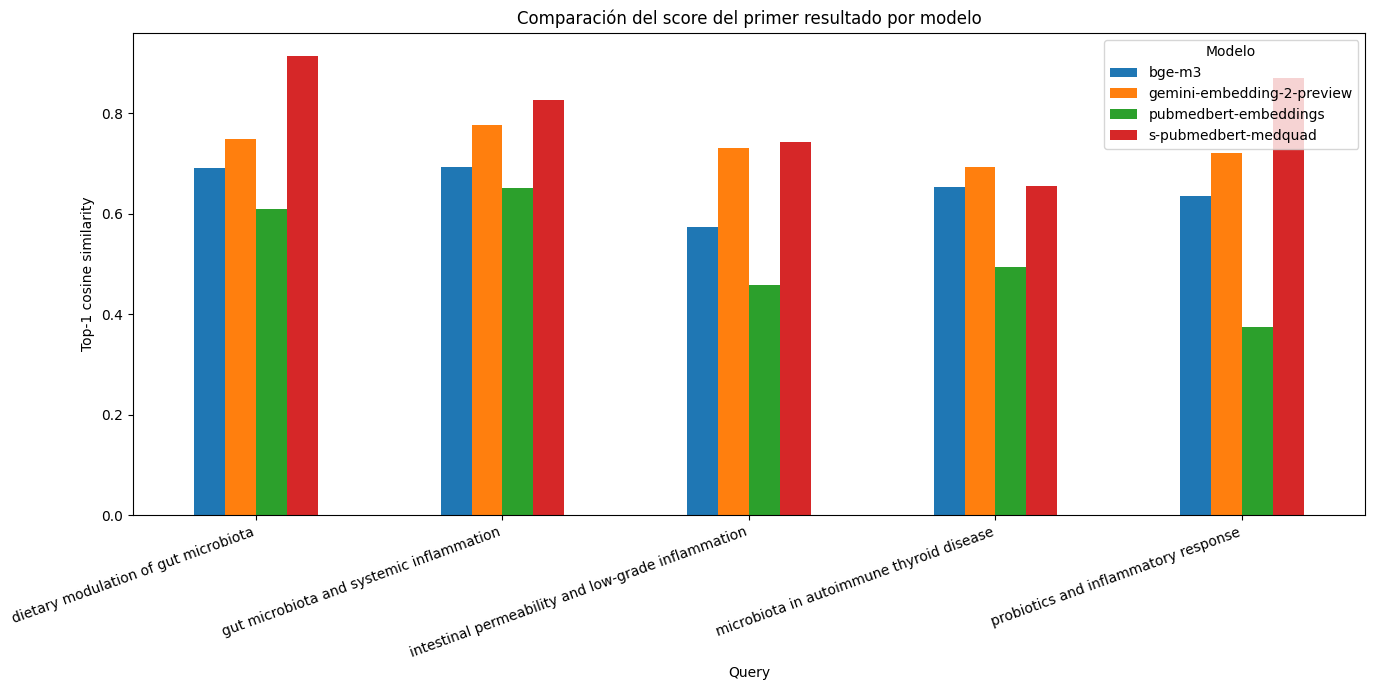

In [148]:
plot_top1_scores(df_summary)

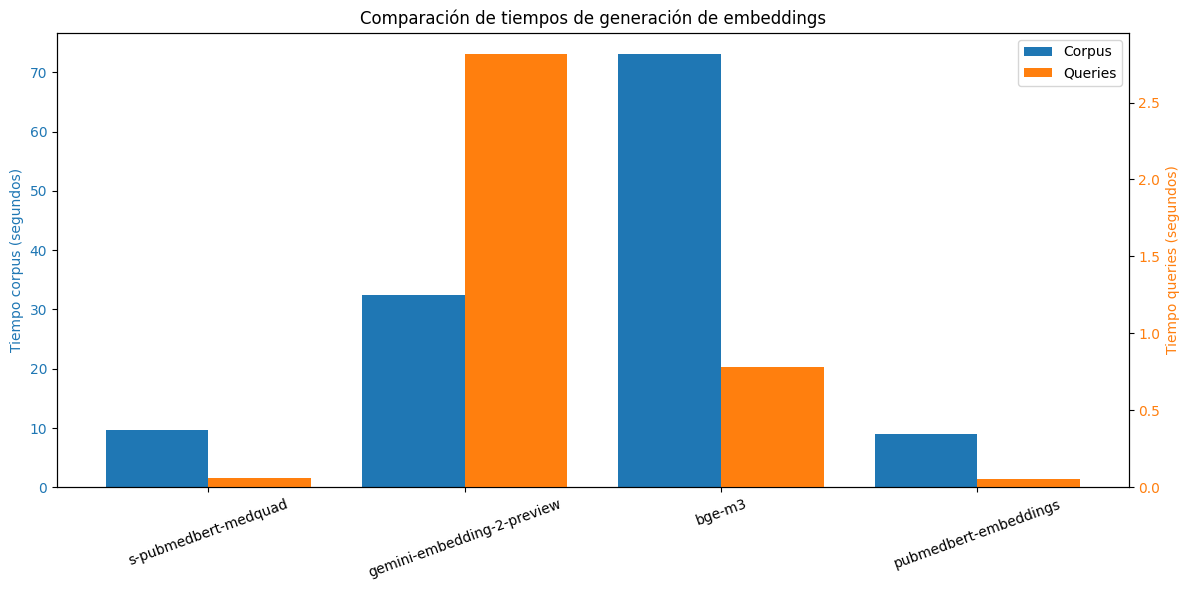

In [150]:
plot_encoding_times(df_models)


Helper para buscar y entender algún artículo mejor

In [151]:
article = next((a for a in articles if a.get("pmid") == "41829891"), None)
article


{'document_id': 'pubmed_41829891',
 'source': 'pubmed',
 'pmid': '41829891',
 'doi': '10.3390/nu18050720',
 'title': 'Migraine and the Gut-Brain Axis-The Role of Microbiome-Targeted Biotics.',
 'abstract': 'Background: Migraine is a highly prevalent and disabling primary headache disorder frequently accompanied by gastrointestinal symptoms and comorbid gastrointestinal diseases. Increasing evidence suggests that alterations in the gut microbiota and dysregulation of the microbiome-gut-brain axis may contribute to migraine pathophysiology through immune activation, oxidative stress, impaired intestinal barrier function, and neuroinflammatory signaling. Objectives: This narrative review aims to summarize current mechanistic and clinical evidence linking the gut-brain axis to migraine, with a particular focus on the potential roles of probiotics, prebiotics, and postbiotics as adjunctive strategies in migraine management. Methods: A narrative synthesis of experimental, translational, and 

## Conclusiones


### Selección del modelo de embeddings

Tras la comparación realizada entre distintos modelos de embeddings, se selecciona **bge-m3** como modelo principal para el sistema.

Aunque los modelos específicos del dominio biomédico, como **S-PubMedBert-MedQuAD**, han mostrado un mayor nivel de especialización en ciertos casos (por ejemplo, identificando mecanismos biológicos o entidades más concretas), su comportamiento resulta menos consistente, introduciendo mayor variabilidad en los resultados y, en ocasiones, recuperando documentos menos alineados con la intención de búsqueda.

La incorporación de **Gemini Embedding** permite añadir un punto de referencia adicional en términos de calidad semántica. Este modelo muestra un comportamiento sólido y coherente en la recuperación, con resultados generalmente bien alineados con las consultas. Sin embargo, presenta limitaciones relevantes para el contexto del proyecto: mayor latencia en la codificación de queries, dimensionalidad elevada (`3072`) y dependencia de un servicio externo, lo que implica mayor coste operativo y menor control sobre el despliegue.

Por el contrario, **bge-m3** presenta un comportamiento más estable y robusto a lo largo de las diferentes consultas, recuperando documentos relevantes de forma consistente, aunque con menor nivel de especialización biomédica.

Dado el carácter exploratorio del proyecto y su enfoque en una demo funcional, se prioriza la consistencia, reproducibilidad y capacidad de despliegue local frente a la especialización puntual o la máxima capacidad semántica. En este contexto, **bge-m3** se considera la opción que ofrece el mejor equilibrio entre robustez, calidad de recuperación y coste operativo.

---

### Medición de tiempos 

Se han medido los tiempos de generación de embeddings diferenciando entre el corpus de documentos y las consultas.

El tiempo de codificación del corpus (`corpus_encoding_time_sec`) corresponde al proceso de transformar todos los documentos en representaciones vectoriales. Este proceso se realiza de forma offline y normalmente solo una vez durante la fase de indexación.

Por otro lado, el tiempo de codificación de las queries (`query_encoding_time_sec`) corresponde a la generación de embeddings para las consultas de usuario. Este proceso se realiza en tiempo de ejecución y tiene un impacto directo en la latencia del sistema.

En los resultados obtenidos se observa que:

- Los modelos basados en **PubMedBERT** son los más rápidos en ambos escenarios.
- **bge-m3** presenta un mayor coste en CPU, especialmente en la generación del corpus.
- **Gemini Embedding** introduce una latencia significativamente superior en queries, debido a su naturaleza como servicio externo.

Por este motivo, aunque ambos tiempos son relevantes, el tiempo de codificación de las queries resulta especialmente crítico en sistemas de recuperación en tiempo real.

---

### Limitaciones

El sistema desarrollado presenta una serie de limitaciones derivadas tanto del enfoque adoptado como del alcance del proyecto:

- **Tamaño reducido del corpus:** El número de artículos indexados (10–50) es limitado en comparación con la magnitud real de PubMed, lo que condiciona la capacidad de recuperación y la diversidad de resultados.

- **Evaluación no sistemática:** La evaluación de los modelos de embeddings se ha realizado de forma cualitativa mediante inspección manual de resultados, sin el uso de métricas formales como precision@k, recall@k o datasets de benchmark.

- **Dependencia de la calidad del abstract:** El sistema se basa principalmente en el abstract del artículo, lo que puede limitar la representación completa del contenido científico.

- **Ausencia de re-ranking:** No se ha implementado una segunda fase de reordenación (reranking), que podría mejorar la precisión de los resultados recuperados.

- **No uso explícito de MeSH en embeddings:** Aunque se utilizan en la fase de búsqueda, los términos MeSH no se integran directamente en la representación vectorial, lo que podría limitar la captura de relaciones semánticas más estructuradas.

- **Dependencia del preprocesamiento:** La calidad del sistema está directamente condicionada por el filtrado en ESearch (`medline[sb]`, `hasabstract`) y la correcta extracción de campos como `ArticleTitle` y `AbstractText`.

---

### Líneas de mejora

A partir de los resultados obtenidos, se identifican varias líneas de mejora que podrían incrementar el rendimiento del sistema:

- **Aumento del corpus:** Escalar el número de artículos indexados para mejorar la cobertura temática y la calidad del retrieval.

- **Estrategia híbrida (BM25 + embeddings):** Combinar búsqueda léxica con búsqueda semántica para mejorar la recuperación inicial.

- **Re-ranking con modelos más potentes:** Incorporar un modelo de reranking (por ejemplo, cross-encoders biomédicos o LLMs) para refinar los resultados obtenidos.

- **Integración explícita de MeSH:** Incorporar términos MeSH como parte del embedding o como filtros estructurados.

- **Evaluación cuantitativa:** Definir métricas objetivas (precision@k, recall@k, MRR) y, si es posible, utilizar datasets de referencia biomédicos.

- **Actualización continua del corpus:** Implementar una estrategia de actualización periódica (por ejemplo, mediante update files de PubMed) para mantener el sistema alineado con nuevas publicaciones.

- **Uso en sistemas RAG:** Integrar el sistema en una arquitectura Retrieval-Augmented Generation para generación de respuestas basadas en evidencia científica.

---

### Insight clave 

En sistemas de recuperación semántica:

- ❌ el mejor modelo no es el que obtiene la mayor puntuación de similitud  
- ✔️ es el que comete menos errores en el ranking de resultados  

La robustez y consistencia del modelo son factores más determinantes que la maximización de scores individuales.

---

### Posible opción avanzada

Una arquitectura más completa podría combinar diferentes modelos en distintas fases:

- **Retrieval:** `bge-m3`  
- **Re-ranking:** `S-PubMedBert-MedQuAD` o un modelo basado en LLM  
